# LangGraph Human-in-the-Loop 教學

Human-in-the-Loop（人在迴圈中）讓工作流程在重要動作前暫停，等待人工檢查。

本例的流程是：

```text
START → Draft Agent → [暫停，等待人工審核] → Publish → END
```

LLM 會先產生公告草稿，但不會立即發布。人可以核准、修改後核准，或拒絕並保持暫停。

## 1. Import libraries

In [1]:
import os
from typing import TypedDict

from IPython.display import Image, display
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph

## 2. 建立 LLM

請先設定系統環境變數 `OPENAI_API_KEY`。如果課程環境使用自訂 endpoint，也可以設定 `OPENAI_BASE_URL`。

In [2]:
llm_options = {
    "api_key": os.environ["OPENAI_API_KEY"],
    "model": os.getenv("OPENAI_MODEL", "gpt-4o-mini"),
    "temperature": 0.0,
}

if os.getenv("OPENAI_BASE_URL"):
    llm_options["base_url"] = os.environ["OPENAI_BASE_URL"]

llm = ChatOpenAI(**llm_options)

## 3. 定義 State

State 保存原始需求、LLM 草稿、流程狀態及最後發布的內容。Checkpointer 會在暫停時保留這些資料。

In [3]:
class State(TypedDict):
    request: str
    draft: str
    status: str
    published_content: str

## 4. 定義 Nodes

`draft_agent` 使用 LLM 產生草稿。`publish` 代表有外部影響的動作；教學中只用 `print()` 模擬，不會真的發布任何內容。

In [4]:
def draft_agent(state: State):
    response = llm.invoke(
        [
            SystemMessage(
                "你是公司內部溝通助理。請依照需求撰寫簡潔、專業的繁體中文公告。"
            ),
            HumanMessage(state["request"]),
        ]
    )

    return {
        "draft": response.content,
        "status": "waiting_for_human_approval",
    }

In [5]:
def publish(state: State):
    print("[模擬發布] 公告已發布：")
    print(state["draft"])

    return {
        "status": "published",
        "published_content": state["draft"],
    }

## 5. 建立具有中斷點的 Graph

`interrupt_before=["publish"]` 表示 Graph 即將執行 Publish Node 前必須暫停。

因為暫停後需要在下一次呼叫中恢復工作，所以必須加入 checkpointer，並在執行時提供 `thread_id`。

In [6]:
workflow = StateGraph(State)

workflow.add_node("draft_agent", draft_agent)
workflow.add_node("publish", publish)

workflow.add_edge(START, "draft_agent")
workflow.add_edge("draft_agent", "publish")
workflow.add_edge("publish", END)

memory = MemorySaver()
graph = workflow.compile(
    checkpointer=memory,
    interrupt_before=["publish"],
)

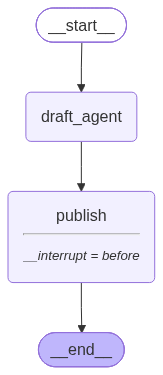

In [7]:
display(Image(graph.get_graph().draw_mermaid_png()))

## 6. 執行到人工審核點

第一次使用 `graph.stream()` 執行 Draft Agent，然後在 Publish Node 前暫停。Stream 結束不代表整個 Graph 已完成；必須用 `get_state()` 檢查 `state.next`。

In [8]:
config = {"configurable": {"thread_id": "announcement-1"}}

initial_state: State = {
    "request": (
        "撰寫一則約 100 字的公告，通知全體員工本週五下午三點進行消防演練，"
        "並提醒大家依照引導迅速前往集合地點。"
    ),
    "draft": "",
    "status": "not_started",
    "published_content": "",
}

for event in graph.stream(
    input=initial_state,
    config=config,
    stream_mode="values",
):
    print("Stream status:", event["status"])

Stream status: not_started
Stream status: waiting_for_human_approval


## 7. 查看暫停狀態

`get_state()` 可以查看 checkpoint。`state.next` 會顯示下一個預定執行的 Node；此時應為 `('publish',)`。

In [9]:
paused_state = graph.get_state(config)

print("Status:", paused_state.values["status"])
print("Next node:", paused_state.next)
print("\nDraft waiting for approval:\n")
print(paused_state.values["draft"])

Status: waiting_for_human_approval
Next node: ('publish',)

Draft waiting for approval:

公告

各位同仁：

為了確保公司安全及提升應急反應能力，本週五下午三點將進行消防演練。請全體員工務必準時參加，並依照引導迅速前往指定集合地點。演練期間請保持安靜，並遵循指示，以確保演練順利進行。感謝大家的配合與支持！

敬祝  
工作愉快  

人事部 敬上


## 8A. 等待人工核准後繼續

執行下一格後，Jupyter 會在 cell 下方顯示輸入框並停止等待。只有輸入 `YES` 才會使用 `graph.stream(input=None, ...)` 從 checkpoint 恢復並執行 Publish；輸入 `NO` 不會發布；輸入 `EDIT` 則可先修改，再進行第二次確認。

In [10]:
human_decision = input("是否核准這份公告？請輸入 YES、NO 或 EDIT：").strip().lower()
approve_words = {"yes", "y", "approve", "同意"}
edit_words = {"edit", "e", "修改"}

if human_decision in approve_words:
    for event in graph.stream(input=None, config=config, stream_mode="values"):
        print("Stream status:", event["status"])
    approved_result = graph.get_state(config).values
    print("Final status:", approved_result["status"])

elif human_decision in edit_words:
    revised_draft = input("請輸入修改後的公告：").strip()

    if not revised_draft:
        print("未輸入內容，Graph 保持暫停。")
    else:
        graph.update_state(
            config=config,
            values={
                "draft": revised_draft,
                "status": "edited_by_human",
            },
        )

        print("\n修改後的公告：\n")
        print(revised_draft)
        final_decision = input("是否發布修改後的公告？請輸入 YES 或 NO：").strip().lower()

        if final_decision in approve_words:
            for event in graph.stream(input=None, config=config, stream_mode="values"):
                print("Stream status:", event["status"])
            approved_result = graph.get_state(config).values
            print("Final status:", approved_result["status"])
        else:
            graph.update_state(config=config, values={"status": "rejected_by_human"})
            print("人工拒絕發布，Publish Node 不會執行。")

else:
    graph.update_state(config=config, values={"status": "rejected_by_human"})
    print("人工拒絕發布，Graph 保持暫停，Publish Node 不會執行。")

Stream status: waiting_for_human_approval
[模擬發布] 公告已發布：
公告

各位同仁：

為了確保公司安全及提升應急反應能力，本週五下午三點將進行消防演練。請全體員工務必準時參加，並依照引導迅速前往指定集合地點。演練期間請保持安靜，並遵循指示，以確保演練順利進行。感謝大家的配合與支持！

敬祝  
工作愉快  

人事部 敬上
Stream status: published
Final status: published


## 8B. 人工修改後再核准

以下使用新的 `thread_id` 建立第二個案例。人在暫停期間可用 `update_state()` 修改草稿；修改後還要再次輸入 `YES`，工作流才會恢復並執行 Publish。

In [12]:
edit_config = {"configurable": {"thread_id": "announcement-2"}}
for event in graph.stream(
    input=initial_state,
    config=edit_config,
    stream_mode="values",
):
    print("Stream status:", event["status"])

draft_before_edit = graph.get_state(edit_config).values["draft"]
print("Original draft:\n")
print(draft_before_edit)

Stream status: not_started
Stream status: waiting_for_human_approval
Original draft:

公告

各位同仁：

為確保公司安全及提升應急反應能力，本週五下午三點將進行消防演練。請全體員工務必準時參加，並依照引導迅速前往指定集合地點。演練期間請保持安靜，並遵循指示，以確保演練順利進行。

感謝大家的配合與支持！

人事部 敬上


In [13]:
human_edited_draft = (
    "【消防演練通知】本週五下午 3 點將進行消防演練。警報響起後，"
    "請停止手邊工作，依現場人員引導，沿指定逃生路線迅速前往一樓廣場集合。"
    "請勿搭乘電梯，並保持冷靜與秩序。"
)

graph.update_state(
    config=edit_config,
    values={
        "draft": human_edited_draft,
        "status": "edited_by_human",
    },
)

edited_state = graph.get_state(edit_config)
print("Edited draft waiting for approval:\n")
print(edited_state.values["draft"])

Edited draft waiting for approval:

【消防演練通知】本週五下午 3 點將進行消防演練。警報響起後，請停止手邊工作，依現場人員引導，沿指定逃生路線迅速前往一樓廣場集合。請勿搭乘電梯，並保持冷靜與秩序。


In [14]:
# 這裡會停下來，等待人工確認修改後的內容。
edit_decision = input("是否核准修改後的公告？請輸入 YES 或 NO：").strip().lower()

if edit_decision in {"yes", "y", "approve", "同意"}:
    for event in graph.stream(
        input=None,
        config=edit_config,
        stream_mode="values",
    ):
        print("Stream status:", event["status"])

    edited_result = graph.get_state(edit_config).values
    print("Final status:", edited_result["status"])
else:
    graph.update_state(
        config=edit_config,
        values={"status": "rejected_by_human"},
    )
    paused_after_rejection = graph.get_state(edit_config)
    print("人工拒絕發布。")
    print("Status:", paused_after_rejection.values["status"])
    print("Next node remains:", paused_after_rejection.next)

人工拒絕發布。
Status: rejected_by_human
Next node remains: ('publish',)


## 8C. 人工拒絕與 `input=None` 的意義

`input=None` **不是拒絕的意思**。它表示：不提供新的初始輸入，直接從這個 `thread_id` 的 checkpoint 繼續執行。

| 呼叫方式 | 意義 |
|---|---|
| `graph.stream(input=initial_state, ...)` | 啟動一個新流程 |
| `graph.stream(input=None, ...)` | 從暫停位置恢復流程 |
| 人工拒絕 | 不呼叫恢復流程，讓 checkpoint 繼續停在 Publish 前 |

下面使用第三個 `thread_id` 示範拒絕。輸入 `NO` 後，程式只更新狀態，不會呼叫 `graph.stream(input=None, ...)`。

In [15]:
reject_config = {"configurable": {"thread_id": "announcement-3"}}

# 先執行到 Publish 前的中斷點。
for event in graph.stream(
    input=initial_state,
    config=reject_config,
    stream_mode="values",
):
    print("Stream status:", event["status"])

reject_state = graph.get_state(reject_config)
print("Next node before human decision:", reject_state.next)
print("\nDraft:\n")
print(reject_state.values["draft"])

rejection_decision = input("是否核准發布？請輸入 YES 或 NO：").strip().lower()

if rejection_decision in {"yes", "y", "approve", "同意"}:
    # YES 才使用 input=None 從 checkpoint 恢復。
    for event in graph.stream(
        input=None,
        config=reject_config,
        stream_mode="values",
    ):
        print("Stream status:", event["status"])
else:
    graph.update_state(
        config=reject_config,
        values={"status": "rejected_by_human"},
    )
    # 注意：拒絕分支刻意沒有呼叫 graph.stream(input=None, ...)。
    rejected_state = graph.get_state(reject_config)
    print("人工已拒絕，沒有執行 Publish。")
    print("Status:", rejected_state.values["status"])
    print("Next node remains:", rejected_state.next)

Stream status: not_started
Stream status: waiting_for_human_approval
Next node before human decision: ('publish',)

Draft:

公告

各位同仁：

為了提升我們的消防安全意識及應變能力，本週五下午三點將進行消防演練。請全體員工務必準時參加，並依照引導迅速前往指定集合地點。演練期間請保持安靜，並遵循指示，以確保演練順利進行。感謝大家的配合與支持！

敬祝
工作愉快

人事部 敬上
人工已拒絕，沒有執行 Publish。
Status: rejected_by_human
Next node remains: ('publish',)


## 8D. 拒絕後改變決定

只要 checkpoint 仍存在，之後可以使用同一個 `thread_id` 再次取得狀態。若人員改為同意，這時才以 `input=None` 恢復。

In [16]:
saved_state = graph.get_state(reject_config)
saved_status = saved_state.values.get("status")

if saved_status != "rejected_by_human":
    print(
        f"略過 8D：8C 並未拒絕這個流程（目前狀態：{saved_status}）。"
    )
    print("若要練習拒絕後恢復，請用新的 thread_id 重跑 8C，並輸入 NO。")

elif not saved_state.next:
    print("流程雖標記為拒絕，但已經沒有可恢復的中斷點。")

else:
    print("確認先前為人工拒絕，目前仍暫停在：", saved_state.next)
    resume_decision = input("現在是否改為同意？請輸入 YES 或 NO：").strip().lower()

    if resume_decision in {"yes", "y", "approve", "同意"}:
        graph.update_state(
            config=reject_config,
            values={"status": "approved_later_by_human"},
        )
        for event in graph.stream(
            input=None,
            config=reject_config,
            stream_mode="values",
        ):
            print("Stream status:", event["status"])
    else:
        print("仍然拒絕，流程繼續保持暫停。")

確認先前為人工拒絕，目前仍暫停在： ('publish',)
Stream status: approved_later_by_human
[模擬發布] 公告已發布：
公告

各位同仁：

為了提升我們的消防安全意識及應變能力，本週五下午三點將進行消防演練。請全體員工務必準時參加，並依照引導迅速前往指定集合地點。演練期間請保持安靜，並遵循指示，以確保演練順利進行。感謝大家的配合與支持！

敬祝
工作愉快

人事部 敬上
Stream status: published


## 重點整理

| 概念 | 本例的用途 |
|---|---|
| `interrupt_before` | 在具有外部影響的 Publish Node 前暫停 |
| `MemorySaver` | 保存暫停時的 State |
| `thread_id` | 找回正確的工作流程 checkpoint |
| `get_state()` | 讓人工查看待審內容與下一個 Node |
| `update_state()` | 在恢復前修改草稿 |
| `graph.stream(input=None, config=...)` | 從中斷點恢復並串流執行結果 |

> `MemorySaver` 只保存於目前 Python 程序。正式系統通常使用資料庫型 checkpointer，並把人工審核介面整合到網頁或內部系統。